# Setup

In [22]:
import sys
from pathlib import Path
from collections import Counter,defaultdict
import random
import matplotlib.pyplot as plt
from PIL import Image
import hashlib
import torch

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.transforms import get_transforms

# Dataset

In [4]:
TRAIN_DIR = PROJECT_ROOT / "data" / "train"
VAL_DIR = PROJECT_ROOT / "data" / "val"
TEST_DIR = PROJECT_ROOT / "data" / "test"

train_dataset = PaintingStyleDataset(root_dir=TRAIN_DIR, transform=None)
val_dataset = PaintingStyleDataset(root_dir=VAL_DIR, transform=None)
test_dataset = PaintingStyleDataset(root_dir=TEST_DIR, transform=None)

In [5]:
all_samples = (
    train_dataset.samples
    + val_dataset.samples
    + test_dataset.samples
)

all_classes = train_dataset.classes
print("Classes:", all_classes)
print("Total images:", len(all_samples))

Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']
Total images: 1422


# Class Distribution

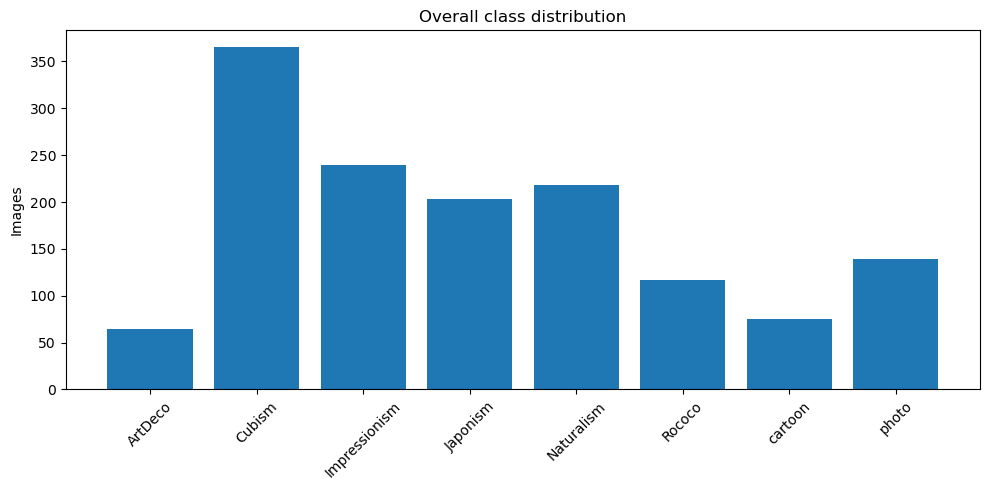

In [6]:
counts = Counter()
for _, label in all_samples:
    counts[all_classes[label]] += 1

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.ylabel("Images")
plt.title("Overall class distribution")
plt.tight_layout()
plt.show()

# Split Comparison

In [7]:
def count_split(dataset):
    c = Counter()
    for _, label in dataset.samples:
        c[dataset.classes[label]] += 1
    return c

print("Train:", count_split(train_dataset))
print("Val:", count_split(val_dataset))
print("Test:", count_split(test_dataset))

Train: Counter({'Cubism': 219, 'Impressionism': 144, 'Naturalism': 130, 'Japonism': 121, 'photo': 83, 'Rococo': 70, 'cartoon': 45, 'ArtDeco': 39})
Val: Counter({'Cubism': 73, 'Impressionism': 48, 'Naturalism': 44, 'Japonism': 41, 'photo': 28, 'Rococo': 23, 'cartoon': 15, 'ArtDeco': 13})
Test: Counter({'Cubism': 73, 'Impressionism': 48, 'Naturalism': 44, 'Japonism': 41, 'photo': 28, 'Rococo': 24, 'cartoon': 15, 'ArtDeco': 13})


# Image Samples

## Samples from different classes

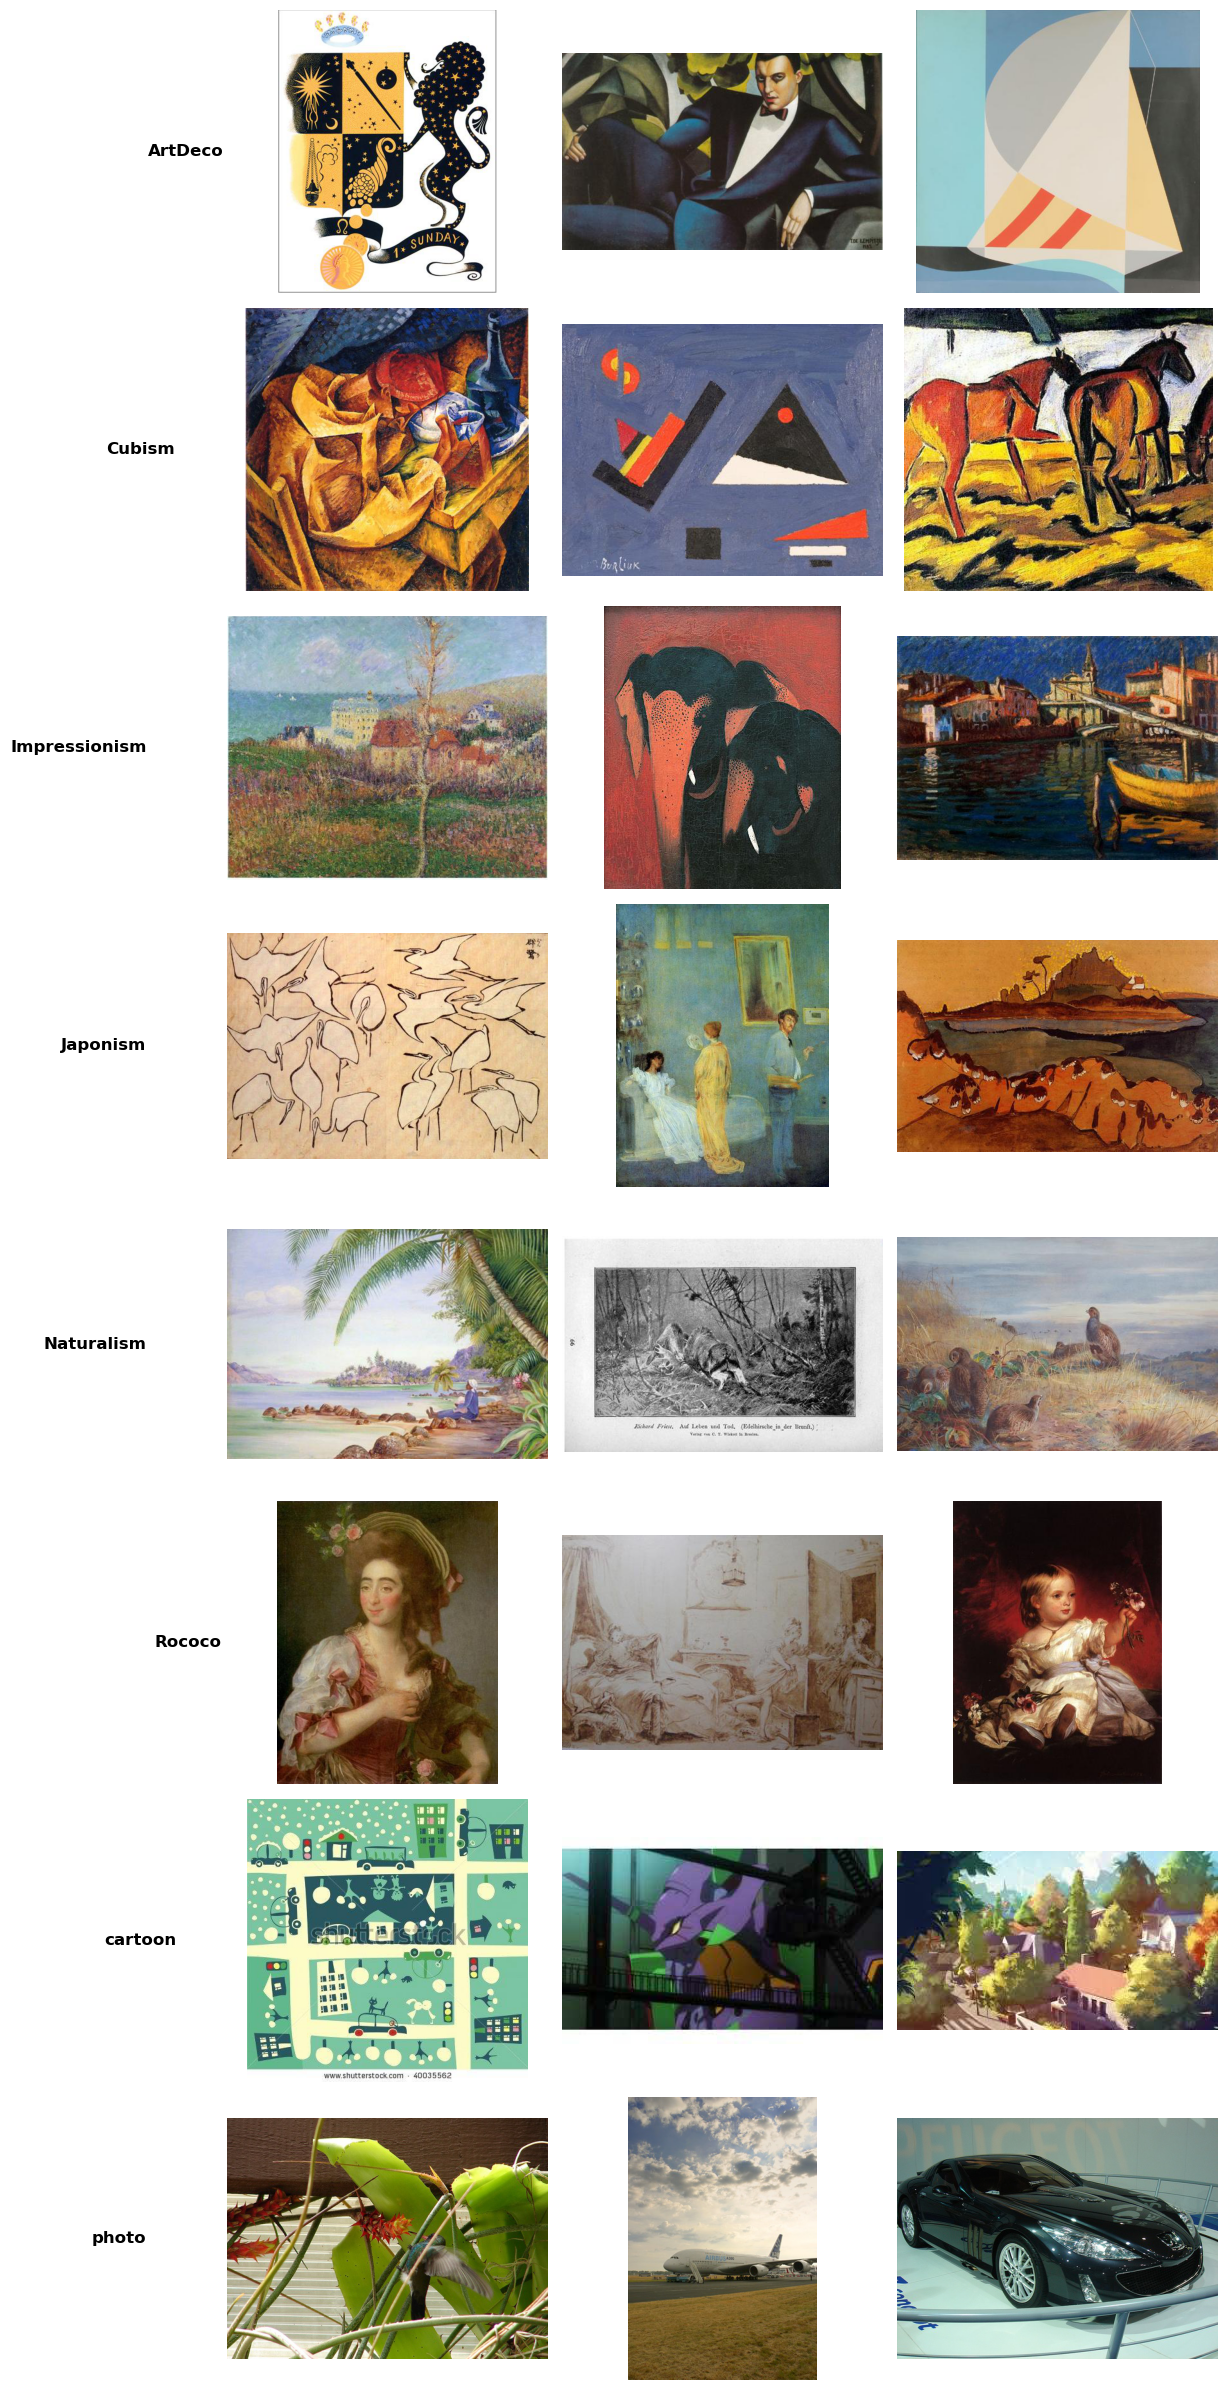

In [12]:
fig, axes = plt.subplots(len(all_classes), 3, figsize=(12, 3 * len(all_classes)))

for i, class_name in enumerate(all_classes):
    class_paths = [p for p, y in all_samples if all_classes[y] == class_name]
    chosen = random.sample(class_paths, min(3, len(class_paths)))

    for j in range(3):
        ax = axes[i, j] if len(all_classes) > 1 else axes[j]
        ax.axis("off")

        if j < len(chosen):
            img = Image.open(chosen[j]).convert("RGB")
            ax.imshow(img)

    row_ax = axes[i, 0] if len(all_classes) > 1 else axes[0]
    row_ax.text(
        -0.25, 0.5, class_name,
        transform=row_ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="center",
        ha="right"
    )

plt.tight_layout()
plt.show()

## Image size distribution

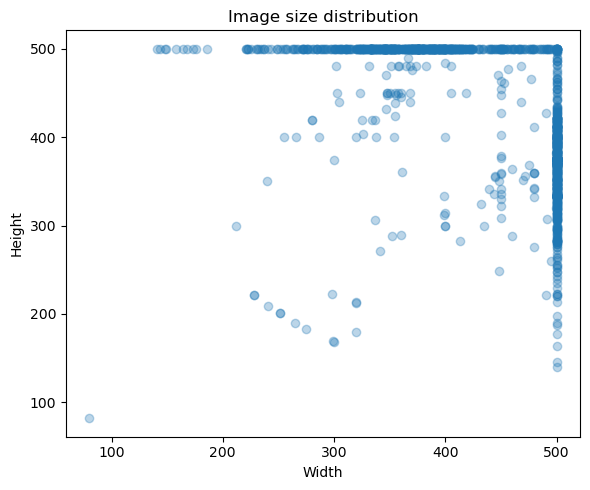

In [9]:
sizes = []
for img_path, _ in all_samples:
    try:
        with Image.open(img_path) as img:
            sizes.append(img.size)
    except Exception:
        pass

widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

plt.figure(figsize=(6, 5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image size distribution")
plt.tight_layout()
plt.show()

## Corrupted images check 

In [10]:
bad_files = []
for img_path, _ in all_samples:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        bad_files.append(img_path)

print("Corrupted files:", len(bad_files))
bad_files[:10]

Corrupted files: 0


[]

## Duplicate images check

In [14]:
def file_hash(path, chunk_size=8192):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

hash_to_files = defaultdict(list)

for img_path, _ in all_samples:
    try:
        h = file_hash(img_path)
        hash_to_files[h].append(img_path)
    except Exception:
        pass

duplicate_groups = [files for files in hash_to_files.values() if len(files) > 1]

print("Number of duplicate groups:", len(duplicate_groups))
print("Number of duplicate files:", sum(len(group) for group in duplicate_groups))
duplicate_groups[:5]

Number of duplicate groups: 1
Number of duplicate files: 2


[[PosixPath('/Users/arpinejanunts/Desktop/iml2-painting-style/data/train/cartoon/trees.jpg'),
  PosixPath('/Users/arpinejanunts/Desktop/iml2-painting-style/data/test/cartoon/download (1).jpg')]]

## Transformed Images 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


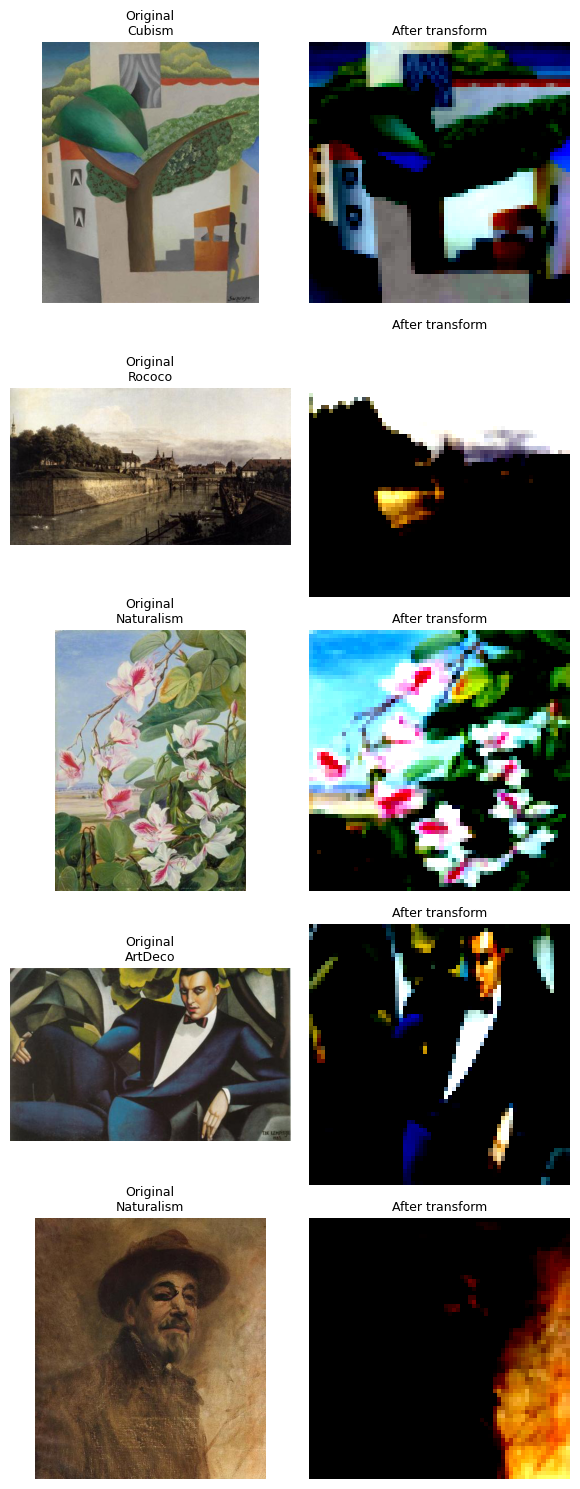

In [21]:
resize_check_transform = get_transforms("val", image_size=64)
random_paths = random.sample([p for p, _ in all_samples], 5)

fig, axes = plt.subplots(len(random_paths), 2, figsize=(6, 3 * len(random_paths)))

for i, img_path in enumerate(random_paths):
    img = Image.open(img_path).convert("RGB")
    transformed_img = resize_check_transform(img)

    transformed_img = transformed_img.permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original\n{img_path.parent.name}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(transformed_img)
    axes[i, 1].set_title("After transform", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()